In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mehmettahiraslan/customer-shopping-dataset/customer_shopping_data.csv
/kaggle/input/datasets/fozia86/my-dashboard-screenshots/dashboard-3.PNG
/kaggle/input/datasets/fozia86/my-dashboard-screenshots/dashboard-1.PNG
/kaggle/input/datasets/fozia86/my-dashboard-screenshots/dashboar-2.PNG


# Smart Retail Reconciler
### Cloud-Based SaaS for Invoice Reconciliation
**Author:** Fozia

## Project Overview

This project automates invoice reconciliation using:

- Flask
- React
- Google BigQuery
- Google Cloud Platform

The dashboard displays:

- Total Invoices
- Total Revenue
- Vendor Analytics
- Revenue Trends

In [2]:
!pip install pandas

In [3]:
import pandas as pd

# Sahi path yeh wala hai:
df = pd.read_csv("/kaggle/input/datasets/mehmettahiraslan/customer-shopping-dataset/customer_shopping_data.csv")

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [5]:
df.groupby("shopping_mall")["price"].sum()

shopping_mall
Cevahir AVM           3433671.84
Emaar Square Mall     3390408.31
Forum Istanbul        3336073.82
Istinye Park          6717077.54
Kanyon               13710755.24
Mall of Istanbul     13851737.62
Metrocity            10249980.07
Metropol AVM          6937992.99
Viaport Outlet        3414019.46
Zorlu Center          3509649.02
Name: price, dtype: float64

In [6]:
# 'invoice_date' ko sahi tarah convert karne ke liye format='mixed' aur dayfirst use karein
df["invoice_date"] = pd.to_datetime(df["invoice_date"], dayfirst=True, format="mixed")

# Monthly sales calculate karne ke liye
monthly = df.groupby(df["invoice_date"].dt.month_name())["price"].sum()
monthly

invoice_date
April        5102478.76
August       5270542.03
December     5295165.36
February     7235297.32
January      7932626.63
July         5552023.57
June         5160345.74
March        6007346.21
May          5346926.82
November     4995141.11
October      5538258.09
September    5115214.27
Name: price, dtype: float64

## Dashboard Screenshots

![Dashboard Page 1](/kaggle/input/my-dashboard-screenshots/dashboard-1.PNG)

![Dashboard Page 2](/kaggle/input/my-dashboard-screenshots/dashboar-2.PNG)

![Dashboard Page 3](/kaggle/input/my-dashboard-screenshots/dashboard-3.PNG)

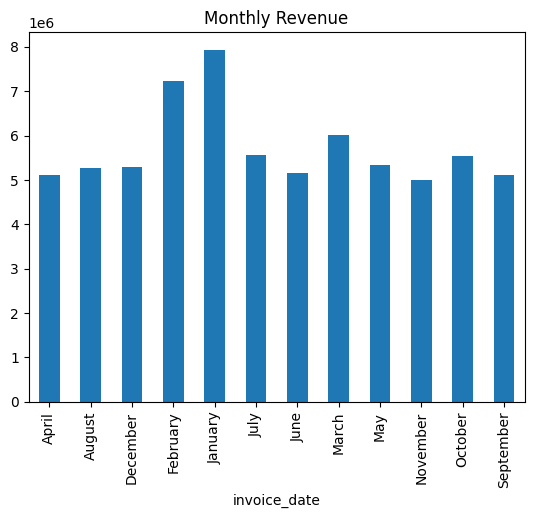

In [7]:
import matplotlib.pyplot as plt

monthly.plot(kind="bar")

plt.title("Monthly Revenue")
plt.show()

In [8]:
import os

os.listdir("/kaggle/input/datasets/fozia86/my-dashboard-screenshots")

['dashboard-3.PNG', 'dashboard-1.PNG', 'dashboar-2.PNG']

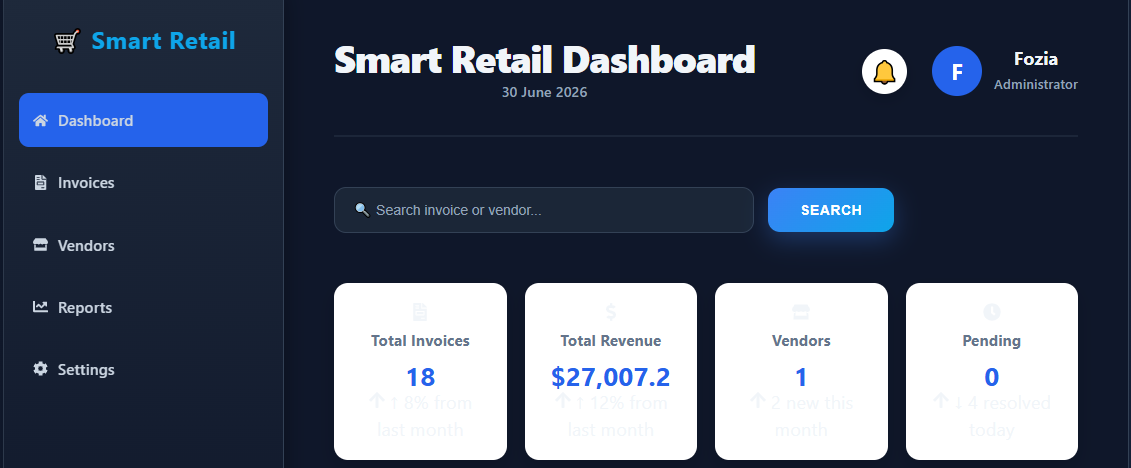

In [9]:
from IPython.display import Image, display

display(Image("/kaggle/input/datasets/fozia86/my-dashboard-screenshots/dashboard-1.PNG"))

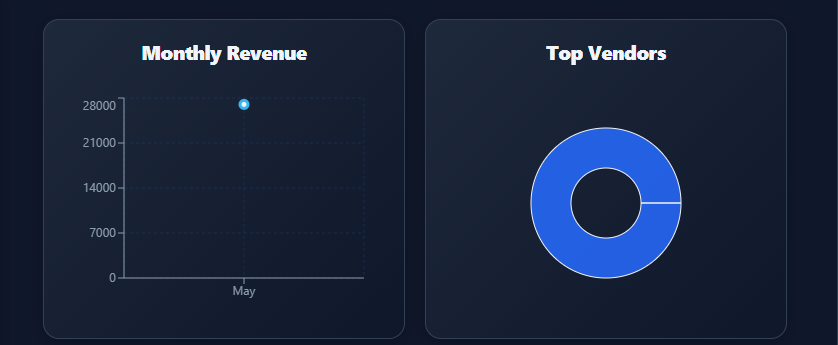

In [10]:
display(Image("/kaggle/input/datasets/fozia86/my-dashboard-screenshots/dashboar-2.PNG"))

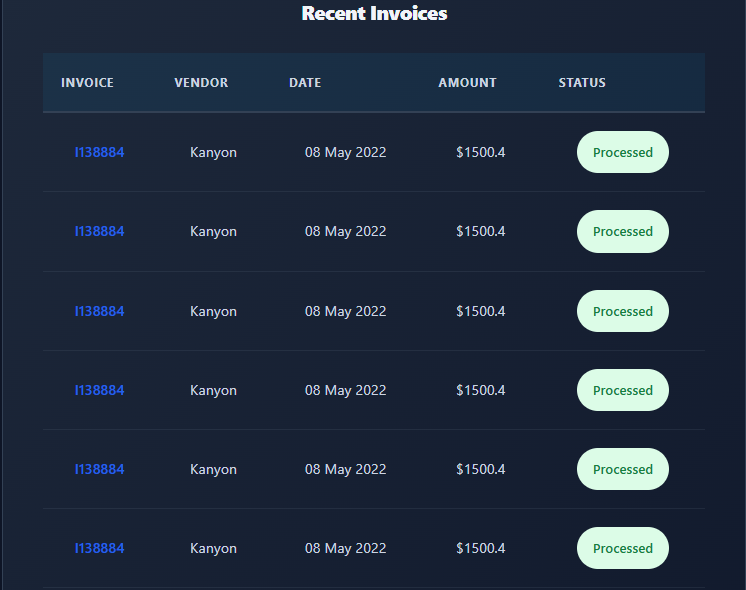

In [11]:
display(Image("/kaggle/input/datasets/fozia86/my-dashboard-screenshots/dashboard-3.PNG"))

## Conclusion

This project demonstrates an end-to-end Smart Retail Reconciler built with:

- React.js Dashboard
- Flask REST API
- Google BigQuery
- Render Deployment

### Features

- Invoice Analytics
- Revenue Dashboard
- Vendor Insights
- Real-time Charts
- Cloud Deployment

### Project Links

**GitHub Repository**

https://github.com/Fozia-86/smart-retail-reconciler

**Live Dashboard**

https://smart-retail-reconciler-1.onrender.com

**Live API**

https://smart-retail-reconciler.onrender.com